# Chapter 12: Natural Language Toolkit

## Notes

- A specialised field of data science is the study of text or *natural
  language*
- The Natural Language Toolkit ([NLTK](https://www.nltk.org/)) is a
  python package for language processing

### NLTK Sample Texts

- NTLTK comes with sample texts that can be downloaded and used
- [Project Gutenburg](https://www.gutenberg.org/) is an online library
  of E-Books
  - Mostly Public Domain works
  - NLTK packages a subset of this collection
- `nltk.download` is used to download data into a local `nltk/corpora`
  directory
  - Data can then be imported for use
  - Stored as a *corpus reader* object
  - A useful feature to download is `punkt_tab`
    - This is a tokenizer used to define sentence endings

In [1]:
import nltk

nltk.download("gutenberg")
nltk.download("punkt_tab")

from nltk.corpus import gutenberg

gutenberg

[nltk_data] Downloading package gutenberg to /home/runner/nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/runner/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!

<PlaintextCorpusReader in '/home/runner/nltk_data/corpora/gutenberg'>

> **Tip**
>
> **Corpus Readers**
>
> Corpus readers are designed to read a specific set of texts. There are
> different corpus readers for different types of text. For plain text
> like books typically the corpus reader is plain text via the
> `PlainTextCorpusReader`.

- Once a corpus is loaded, individual texts can be listed via the
  `fileids` method.
  - Text’s are stored as files

In [2]:
from nltk.corpus import gutenberg

gutenberg.fileids()

['austen-emma.txt',
 'austen-persuasion.txt',
 'austen-sense.txt',
 'bible-kjv.txt',
 'blake-poems.txt',
 'bryant-stories.txt',
 'burgess-busterbrown.txt',
 'carroll-alice.txt',
 'chesterton-ball.txt',
 'chesterton-brown.txt',
 'chesterton-thursday.txt',
 'edgeworth-parents.txt',
 'melville-moby_dick.txt',
 'milton-paradise.txt',
 'shakespeare-caesar.txt',
 'shakespeare-hamlet.txt',
 'shakespeare-macbeth.txt',
 'whitman-leaves.txt']

- Corpus readers support various mechanisms for analysing text
  - Text can be loaded broken into
    - Words
    - Sentences
    - Paragraphs
- For example, loading Shakespeare’s *Julius Caesar*

In [3]:
from nltk.corpus import gutenberg

caesar = gutenberg.sents("shakespeare-caesar.txt")

caesar

[['[', 'The', 'Tragedie', 'of', 'Julius', 'Caesar', 'by', 'William', 'Shakespeare', '1599', ']'], ['Actus', 'Primus', '.'], ...]

- As mentioned to parse text into sentences you need to use a
  *tokenizer*
- Punkt is a general-purpose tokenizer
  - Designed to work across multiple languages
- As mentioned before NLTK will download into a local `nltk_data` folder
  - It is divided up into,
    1.  *corpora*
        - Texts to analyse
    2.  *tokenizers*
        - Text analysis engines

In [4]:
!ls ~/nltk_data

corpora  tokenizers

- Inside the corpora directory we can see the text set’s we have
  downloaded

In [5]:
!ls ~/nltk_data/corpora

brown      gutenberg      names      stopwords
brown.zip  gutenberg.zip  names.zip  stopwords.zip

- and of-course the text’s they contain

In [6]:
!ls ~/nltk_data/corpora/gutenberg

README             burgess-busterbrown.txt  milton-paradise.txt
austen-emma.txt        carroll-alice.txt    shakespeare-caesar.txt
austen-persuasion.txt  chesterton-ball.txt  shakespeare-hamlet.txt
austen-sense.txt       chesterton-brown.txt shakespeare-macbeth.txt
bible-kjv.txt          chesterton-thursday.txt  whitman-leaves.txt
blake-poems.txt        edgeworth-parents.txt
bryant-stories.txt     melville-moby_dick.txt

- Inside the tokenizers directory we can see the tokenizers we’ve
  downloaded

In [7]:
!ls ~/nltk_data/tokenizers

punkt_tab  punkt_tab.zip

- and within the `punkt_tab` directory we can see the languages it
  supports

In [8]:
!ls ~/nltk_data/tokenizers/punkt_tab

README  dutch     finnish  greek      norwegian   russian  swedish
czech   english   french   italian    polish      slovene  turkish
danish  estonian  german   malayalam  portuguese  spanish

### Frequency Distributions

- The `nltk.FreqDist` class can be used to examine the occurrences of
  words within a text
- Can look at,
  - Which words are the most frequent
  - How many unique words there are
  - etc.

In [9]:
import nltk
from nltk.corpus import gutenberg

caesar = gutenberg.words("shakespeare-caesar.txt")
caesar_dist = nltk.FreqDist(caesar)
caesar_dist.most_common(15)

[(',', 2204),
 ('.', 1296),
 ('I', 531),
 ('the', 502),
 (':', 499),
 ('and', 409),
 ("'", 384),
 ('to', 370),
 ('you', 342),
 ('of', 336),
 ('?', 296),
 ('not', 249),
 ('a', 240),
 ('is', 230),
 ('And', 218)]

- NLTK defines a word as any piece of text that is not whitespace
- This means punctuation is counted as separate “words”
- To filter out punctuation we can use the built-in `string` library
  - Contains a `punctuation` attribute
    - String containing every punctuation character
- For example, to filter the punctuation out of the above example, we
  can,

In [10]:
import string

import nltk
from nltk.corpus import gutenberg

print("punctuation:", string.punctuation)

caesar = gutenberg.words("shakespeare-caesar.txt")

caesar_filtered = [word for word in caesar if word not in string.punctuation]

print("Number of punctuation symbols:", len(caesar) - len(caesar_filtered))

caesar_dist = nltk.FreqDist(caesar_filtered)
caesar_dist.most_common(15)

punctuation: !"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
Number of punctuation symbols: 4960

[('I', 531),
 ('the', 502),
 ('and', 409),
 ('to', 370),
 ('you', 342),
 ('of', 336),
 ('not', 249),
 ('a', 240),
 ('is', 230),
 ('And', 218),
 ('d', 215),
 ('in', 204),
 ('that', 200),
 ('Caesar', 189),
 ('my', 188)]

> **Note**
>
> **List Comprehension**
>
> The syntax we’ve used above is called a list comprehension, and is
> designed for quickly creating a list based on the elements of an
> existing collection. You could achieve the same with a simple `for`
> loop as described in [Chapter
> 5](../../1_learning-python-in-a-notebook-environment/Chapter_05/Chapter_05.qmd),
> but the list comprehension syntax is more compact. List comprehensions
> will be discussed in more detail later.

- Another common filtering step is remove common words that don’t
  provide much contextual understanding
  - These are simple words like “the”, “and”, “as” etc.
  - Commonly referred to as *stopwords*
- NLTK provides the `stopwords` corpus which can be downloaded to
  perform this filtering

In [11]:
import nltk

nltk.download("stopwords")

from nltk.corpus import stopwords

english_stopwords = stopwords.words("english")
english_stopwords[:10]  # show the first ten stopwords

[nltk_data] Downloading package stopwords to /home/runner/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an']

- Once we’ve downloaded the `stopwords` corpus we can use it to filter
  out the these common words from our analysis of Julius Caesar.

In [12]:
import string

import nltk
from nltk.corpus import gutenberg, stopwords

caesar = gutenberg.words("shakespeare-caesar.txt")

# filter out punctuation
caesar_punctuation_filtered = [
    word for word in caesar if word not in string.punctuation
]

# filter out stopwords
english_stopwords = stopwords.words("english")
caesar_filtered = [
    word
    for word in caesar_punctuation_filtered
    if word.lower() not in english_stopwords
]

print("Number of stop words:", len(caesar_punctuation_filtered) - len(caesar_filtered))

caesar_dist = nltk.FreqDist(caesar_filtered)
caesar_dist.most_common(15)

Number of stop words: 9746

[('Caesar', 189),
 ('Brutus', 161),
 ('Bru', 153),
 ('haue', 128),
 ('shall', 107),
 ('Cassi', 107),
 ('thou', 100),
 ('Cassius', 85),
 ('Antony', 75),
 ('know', 66),
 ('Enter', 63),
 ('men', 62),
 ('vs', 62),
 ('man', 58),
 ('thee', 55)]

- With the extraneous words removed we can start deriving insight into
  the text
  - For example, the above shows Caesar and Brutus are mentioned the
    most out of any other characters
- The `FreqDist` class also comes with a bunch of other methods for
  analysing a text

caesar_dist.max(): Caesar
caesar_dist['Cassi']: 107
caesar_dist.freq('Cassi'): 0.009616248764267098
caesar_dist.N(): 11127
 Caesar  Brutus     Bru    haue   shall   Cassi    thou Cassius  Antony    know 
    189     161     153     128     107     107     100      85      75      66 
caesar_dist.tabulate(10):
 None

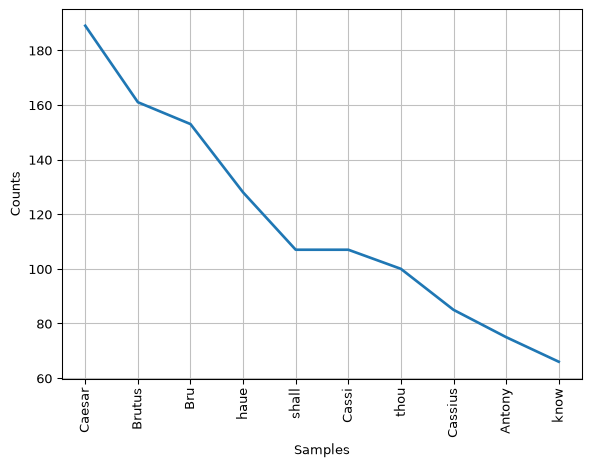

In [13]:
import string

import nltk
from nltk.corpus import gutenberg, stopwords

caesar = gutenberg.words("shakespeare-caesar.txt")

# filter out punctuation
caesar_filtered = [word for word in caesar if word not in string.punctuation]

# filter out stopwords
english_stopwords = stopwords.words("english")
caesar_filtered = [
    word for word in caesar_filtered if word.lower() not in english_stopwords
]

caesar_dist = nltk.FreqDist(caesar_filtered)


print("caesar_dist.max():", caesar_dist.max())  # The word with the most appearances

print(
    "caesar_dist['Cassi']:", caesar_dist["Cassi"]
)  # perform a key lookup for the count of a particular word

print(
    "caesar_dist.freq('Cassi'):", caesar_dist.freq("Cassi")
)  # Count of the word divided by the total count

print("caesar_dist.N():", caesar_dist.N())  # The number of words

print(
    "caesar_dist.tabulate(10):\n", caesar_dist.tabulate(10)
)  # Display the count for the top 10 words

# plot the 10 most frequent words
caesar_dist.plot(10)

### Text Objects

- The `Text` class is provides functionality for exploring a text
- Is initialised from a list of words

In [14]:
import nltk
from nltk.corpus import gutenberg
from nltk.text import Text

caesar = gutenberg.words("shakespeare-caesar.txt")
caesar_t = Text(caesar)
type(caesar_t)

nltk.text.Text

- `Text` provides a number of useful methods for studying a text
  - `concordance`
    - Show’s the context around a given word
  - `collocations`
    - Displays words commonly appearing together
  - `similar` finds words appearing in a similar context
  - `findall` returns all text matching a regular expression
    - Use `<` and `>` to define word boundaries
    - `*` as a match anything wildcard
  - `dispersion_plot` compares where words appear in a given text

caesar_t.concordance('Antony', lines=5):
Displaying 5 of 75 matches:
efulnesse . Exeunt . Enter Caesar , Antony for the Course , Calphurnia , Porti
rt Of that quicke Spirit that is in Antony : Let me not hinder Cassius your de
. He loues no Playes , As thou dost Antony : he heares no Musicke ; Seldome he
fer ' d him the Crowne ? Cask . Why Antony Bru . Tell vs the manner of it , ge
, I did not marke it . I sawe Marke Antony offer him a Crowne , yet ' twas not

caesar_t.collocations(num=4):
Mark Antony; Marke Antony; Good morrow; Caius Ligarius

caesar_t.similar('Caesar'):
me it brutus you he rome that cassius this if men worke him vs feare
world thee what know day

caesar_t.findall(r'<O><C.*>'):

O Cicero; O Cassius; O Conspiracie; O Caesar; O Caesar; O Caesar; O
Constancie; O Caesar; O Caesar; O Caesar; O Cassius; O Cassius; O
Cassius; O Coward; O Cassius; O Clitus

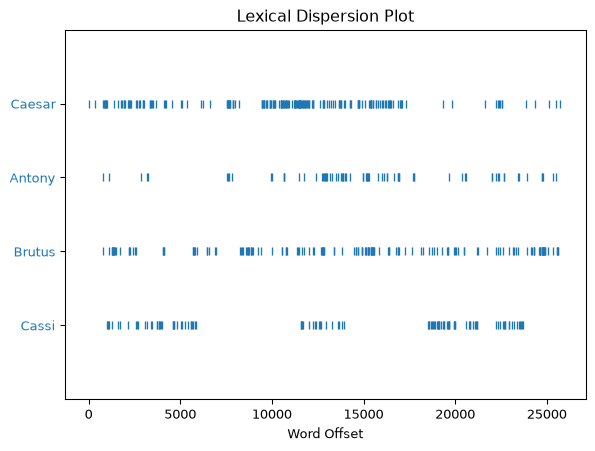

In [15]:
import nltk
from nltk.corpus import gutenberg
from nltk.text import Text

caesar = gutenberg.words("shakespeare-caesar.txt")
caesar_t = Text(caesar)

print("caesar_t.concordance('Antony', lines=5):")
(caesar_t.concordance("Antony", lines=5),)


print("\ncaesar_t.collocations(num=4):")
caesar_t.collocations(num=4)

print("\ncaesar_t.similar('Caesar'):")
caesar_t.similar("Caesar")

print("\ncaesar_t.findall(r'<O><C.*>'):\n")
caesar_t.findall(r"<O><C.*>")

caesar_t.dispersion_plot(["Caesar", "Antony", "Brutus", "Cassi"])

### Classifying Text

- Classifier classes are designed to label text data
- To label text data typically you need prepare data with category or
  label features
  - Can then build a model (See [Chapter
    11](../Chapter_11/Chapter_11.qmd))
- This section steps through a simple example using the [Brown
  Corpus](http://korpus.uib.no/icame/brown/bcm.html)
  - This corpus simplifies the process since the data comes pre-labelled
- For example, let us consider attempting to label paragraphs as either
  *editorial* or *fiction*
  - We might do this based on the appearance of certain words
  - Here a simple dictionary `tell_words`
- First need to download our data

In [16]:
import nltk

nltk.download('brown')

from nltk.corpus import brown

brown

[nltk_data] Downloading package brown to /home/runner/nltk_data...
[nltk_data]   Package brown is already up-to-date!

<CategorizedTaggedCorpusReader in '/home/runner/nltk_data/corpora/brown'>

- Now we need to load our data, clean it and define our `tell_words`
  dictionary

In [17]:
import nltk
from nltk.corpus import brown, stopwords

tell_words = {
    "american",
    "city",
    "congress",
    "country",
    "county",
    "editor",
    "fact",
    "government",
    "national",
    "nuclear",
    "party",
    "peace",
    "political",
    "power",
    "president",
    "public",
    "state",
    "states",
    "united",
    "war",
    "washington",
    "world",
    "big",
    "church",
    "every",
    "eyes",
    "face",
    "felt",
    "found",
    "god",
    "hand",
    "head",
    "home",
    "house",
    "knew",
    "moment",
    "night",
    "room",
    "seemed",
    "stood",
    "think",
    "though",
    "thought",
    "told",
    "voice",
}

english_stopwords = stopwords.words("english")
editorial_paragraphs = brown.paras(categories="editorial")  # load editorial paragraphs
fiction_paragraphs = brown.paras(categories="fiction")  # load only fiction paragraphs

print("There are", len(editorial_paragraphs), "editorial paragraphs")
print("There are", len(fiction_paragraphs), "fiction paragraphs")

There are 1003 editorial paragraphs
There are 1043 fiction paragraphs

- Each paragraph is a list of lists
  - Each sub-list is a sentence in a paragraph
- For this analysis we only care about the unique words in a paragraph
  - So we want to flatten each paragraph into the set of words it
    contains
  - We also want to normalise the words to be all lower case for easier
    analysis
  - We can do this with a simple function and a *set comprehension* (See
    the earlier discussion of list comprehensions)
    - We’ve added *type hints* to help the reader understand what is
      happening to the dimensions of the data

In [18]:
import nltk
from nltk.corpus import brown, stopwords
from typing import Sequence

tell_words = {
    "american",
    "city",
    "congress",
    "country",
    "county",
    "editor",
    "fact",
    "government",
    "national",
    "nuclear",
    "party",
    "peace",
    "political",
    "power",
    "president",
    "public",
    "state",
    "states",
    "united",
    "war",
    "washington",
    "world",
    "big",
    "church",
    "every",
    "eyes",
    "face",
    "felt",
    "found",
    "god",
    "hand",
    "head",
    "home",
    "house",
    "knew",
    "moment",
    "night",
    "room",
    "seemed",
    "stood",
    "think",
    "though",
    "thought",
    "told",
    "voice",
}

# Load the datasets
english_stopwords = stopwords.words("english")
editorial_paragraphs = brown.paras(categories="editorial")  # load editorial paragraphs
fiction_paragraphs = brown.paras(categories="fiction")  # load only fiction paragraphs


# Clean the data format


def flatten(paragraph: Sequence[Sequence[str]]) -> Set[str]:
    return {word.lower() for sentence in paragraph for word in sentence}


editorial_paragraphs_flattened = [
    flatten(paragraph) for paragraph in editorial_paragraphs
]
fiction_paragraphs_flattened = [flatten(paragraph) for paragraph in fiction_paragraphs]

print(
    "Flattened editorial paragraphs:\n",
    "\n".join([str(paragraph) for paragraph in editorial_paragraphs_flattened][:5]),
)

Flattened editorial paragraphs:
 {'of', 'to', 'governor', 'in', 'decision', 'struggle', 'general', 'has', 'atmosphere', 'much', 'adjourns', 'faced', 'with', 'conjunction', 'an', 'immediately', 'squarely', 'convened', '.', 'abandoning', 'from', 'day', 'public', 'session', 'was', 'issue', 'a', 'education', 'and', 'the', ',', 'showdown', 'brought', 'on', 'it', 'crisis', 'assembly', 'which', 'schools', 'risk', 'today', 'met', 'good', 'not', 'performed'}
{'legislators', 'to', 'followed', 'in', 'decision', 'general', 'has', 'for', 'powers', 'final', 'strengthening', 'way', 'need', 'budgeting', 'tackle', '.', 'historic', 'information', 'budget', 'there', 'been', 'went', 'provide', 'appropriations', 'a', 'they', 'procedures', 'executive', 'and', 'the', 'fight', 'decided', ',', 'opened', 'assembly', 'but', 'which'}
{'insured', 'next', 'of', 'to', 'crisis-to-crisis', 'in', 'this', 'financial', 'government', 'them', 'if', 'for', 'now', 'musts', 'finance', '.', 'years', 'from', 'instance', 'sessio

- Next we need to associate the labels to each of our data sets
- Then combine together into a test set
  - We can do this via the `itertools` built-in library
    - Provides functions for simplifying the way of combining multi
      iterators
    - Here `product` is used to generate a cartesian product, in this
      case adding the label to each element of the flattened data to
      form a tuple
      - We could also do this with a list comprehension, and it’s
        arguably cleaner to do so
      - Goal here is demonstrating `itertools`
    - The two labelled datasets can then be merged via `itertools.chain`
      which combines multiple iterators into one iterator sequentially
      over each dataset
- We want to avoid the classifier picking up on some ordering in the
  data set (i.e. the first $x$ samples are all editorial, then the
  remaining are fiction)
  - So we randomly shuffle the data set via `shuffle` from the `random`
    built-in module

In [19]:
import itertools
import random

import nltk
from nltk.corpus import brown, stopwords
from typing import Sequence

tell_words = {
    "american",
    "city",
    "congress",
    "country",
    "county",
    "editor",
    "fact",
    "government",
    "national",
    "nuclear",
    "party",
    "peace",
    "political",
    "power",
    "president",
    "public",
    "state",
    "states",
    "united",
    "war",
    "washington",
    "world",
    "big",
    "church",
    "every",
    "eyes",
    "face",
    "felt",
    "found",
    "god",
    "hand",
    "head",
    "home",
    "house",
    "knew",
    "moment",
    "night",
    "room",
    "seemed",
    "stood",
    "think",
    "though",
    "thought",
    "told",
    "voice",
}

# Load the data
english_stopwords = stopwords.words("english")
editorial_paragraphs = brown.paras(categories="editorial")  # load editorial paragraphs
fiction_paragraphs = brown.paras(categories="fiction")  # load only fiction paragraphs


# clean the data
def flatten(paragraph: Sequence[Sequence[str]]) -> Set[str]:
    return {word.lower() for sentence in paragraph for word in sentence}


editorial_paragraphs_flattened = [
    flatten(paragraph) for paragraph in editorial_paragraphs
]
fiction_paragraphs_flattened = [flatten(paragraph) for paragraph in fiction_paragraphs]

# Label the data
editorial_paragraphs_labelled = itertools.product(
    editorial_paragraphs_flattened, ("editorial",)
)
fiction_paragraphs_labelled = itertools.product(
    editorial_paragraphs_flattened, ("fiction",)
)
labelled_data = list(
    itertools.chain(editorial_paragraphs_labelled, fiction_paragraphs_labelled)
)

random.shuffle(labelled_data)
labelled_data[0]

({',',
  '.',
  'about',
  'and',
  'any',
  'are',
  'armed',
  'besides',
  'competing',
  'corruptible',
  "don't",
  'enough',
  'is',
  'journalists',
  'longer',
  'media',
  'more',
  'need',
  'no',
  'now',
  'numerous',
  'of',
  'protection',
  'public',
  'sophistication',
  'the',
  'there',
  'this',
  'type',
  'we',
  'with'},
 'fiction')

- To use the classifier we have to convert our paragraphs into a
  *feature set*
  - Form of a dictionary mapping features to values
- Here our features are the presence or absence of a given tell word
  - Marked via a boolean flag
- Again can be implemented via a simple function `define_features`
  - We use a *dictionary comprehension* for the function implementation
    (See again the discussion of list comprehensions and set
    comprehensions)

In [20]:
import itertools
import random

import nltk
from nltk.corpus import brown, stopwords
from typing import Sequence

tell_words = {
    "american",
    "city",
    "congress",
    "country",
    "county",
    "editor",
    "fact",
    "government",
    "national",
    "nuclear",
    "party",
    "peace",
    "political",
    "power",
    "president",
    "public",
    "state",
    "states",
    "united",
    "war",
    "washington",
    "world",
    "big",
    "church",
    "every",
    "eyes",
    "face",
    "felt",
    "found",
    "god",
    "hand",
    "head",
    "home",
    "house",
    "knew",
    "moment",
    "night",
    "room",
    "seemed",
    "stood",
    "think",
    "though",
    "thought",
    "told",
    "voice",
}

# Load the data
english_stopwords = stopwords.words("english")
editorial_paragraphs = brown.paras(categories="editorial")  # load editorial paragraphs
fiction_paragraphs = brown.paras(categories="fiction")  # load only fiction paragraphs


# clean the data
def flatten(paragraph: Sequence[Sequence[str]]) -> Set[str]:
    return {word.lower() for sentence in paragraph for word in sentence}


editorial_paragraphs_flattened = [
    flatten(paragraph) for paragraph in editorial_paragraphs
]
fiction_paragraphs_flattened = [flatten(paragraph) for paragraph in fiction_paragraphs]

# Label the data
editorial_paragraphs_labelled = itertools.product(
    editorial_paragraphs_flattened, ("editorial",)
)
fiction_paragraphs_labelled = itertools.product(
    editorial_paragraphs_flattened, ("fiction",)
)
labelled_data = list(
    itertools.chain(editorial_paragraphs_labelled, fiction_paragraphs_labelled)
)
random.shuffle(labelled_data)


# create the feature sets
def define_features(paragraph: Set[str], feature_words: Set[str]) -> dict[str, bool]:
    features = {word: word in paragraph for word in feature_words}
    return features


feature_data = [
    (define_features(paragraph, tell_words), label)
    for paragraph, label in labelled_data
]

# split into test and training
train_data = feature_data[:1400]
test_data = feature_data[1400:]

print(
    "test data sample:\n",
    "\n".join([str(test_entry) for test_entry in test_data[0:10]]),
)

test data sample:
 ({'united': False, 'national': False, 'power': False, 'church': False, 'told': False, 'government': False, 'president': False, 'knew': False, 'hand': False, 'thought': False, 'face': False, 'head': False, 'country': False, 'seemed': False, 'editor': False, 'peace': False, 'city': False, 'public': False, 'washington': False, 'felt': False, 'stood': False, 'world': False, 'congress': False, 'night': False, 'eyes': False, 'found': False, 'though': False, 'nuclear': False, 'county': False, 'war': False, 'moment': False, 'state': False, 'party': False, 'think': False, 'god': False, 'political': False, 'room': False, 'house': False, 'big': False, 'every': False, 'states': False, 'home': False, 'voice': False, 'american': False, 'fact': False}, 'editorial')
({'united': True, 'national': False, 'power': False, 'church': False, 'told': True, 'government': True, 'president': False, 'knew': False, 'hand': False, 'thought': False, 'face': False, 'head': False, 'country': False, 

- Now that the data has been cleaned and converted to the required input
  format we can classify it
- Here we train an `nltk.NaiveBayesClassifier` on the training set, and
  then assess it’s effectiveness on the test data

In [21]:
import itertools
import random

import nltk
from nltk.corpus import brown, stopwords
from typing import Sequence

tell_words = {
    "american",
    "city",
    "congress",
    "country",
    "county",
    "editor",
    "fact",
    "government",
    "national",
    "nuclear",
    "party",
    "peace",
    "political",
    "power",
    "president",
    "public",
    "state",
    "states",
    "united",
    "war",
    "washington",
    "world",
    "big",
    "church",
    "every",
    "eyes",
    "face",
    "felt",
    "found",
    "god",
    "hand",
    "head",
    "home",
    "house",
    "knew",
    "moment",
    "night",
    "room",
    "seemed",
    "stood",
    "think",
    "though",
    "thought",
    "told",
    "voice",
}

# Load the data
english_stopwords = stopwords.words("english")
editorial_paragraphs = brown.paras(categories="editorial")  # load editorial paragraphs
fiction_paragraphs = brown.paras(categories="fiction")  # load only fiction paragraphs


# clean the data
def flatten(paragraph: Sequence[Sequence[str]]) -> Set[str]:
    return {word.lower() for sentence in paragraph for word in sentence}


editorial_paragraphs_flattened = [
    flatten(paragraph) for paragraph in editorial_paragraphs
]
fiction_paragraphs_flattened = [flatten(paragraph) for paragraph in fiction_paragraphs]

# Label the data
editorial_paragraphs_labelled = itertools.product(
    editorial_paragraphs_flattened, ("editorial",)
)
fiction_paragraphs_labelled = itertools.product(
    editorial_paragraphs_flattened, ("fiction",)
)
labelled_data = list(
    itertools.chain(editorial_paragraphs_labelled, fiction_paragraphs_labelled)
)
random.shuffle(labelled_data)


# create the feature sets
def define_features(paragraph: Set[str], feature_words: Set[str]) -> dict[str, bool]:
    features = {word: word in paragraph for word in feature_words}
    return features


feature_data = [
    (define_features(paragraph, tell_words), label)
    for paragraph, label in labelled_data
]

# split into test and training
train_data = feature_data[:1400]
test_data = feature_data[1400:]

# train and test the model
bayes = nltk.NaiveBayesClassifier.train(train_data)  # Train the model
print(bayes.classify(train_data[0][0]))  # classify a training set paragraph

print(
    "Which features (tell words) were assessed to be the most significant indicators?"
)
bayes.show_most_informative_features()

print("Accuracy:", nltk.classify.accuracy(bayes, test_data))  # Assess the accuracy

fiction
Which features (tell words) were assessed to be the most significant indicators?
Most Informative Features
                  seemed = True           fictio : editor =      2.4 : 1.0
                    told = True           editor : fictio =      2.3 : 1.0
                     god = True           fictio : editor =      1.6 : 1.0
              washington = True           editor : fictio =      1.5 : 1.0
                 thought = True           editor : fictio =      1.5 : 1.0
                   night = True           editor : fictio =      1.4 : 1.0
                   voice = True           fictio : editor =      1.4 : 1.0
                    head = True           editor : fictio =      1.4 : 1.0
                    home = True           fictio : editor =      1.3 : 1.0
                  moment = True           editor : fictio =      1.3 : 1.0
Accuracy: 0.4141914191419142

- The model should perform better than a 50 / 50 guess
  - Obviously we could use a wider set of features rather than just the
    presence of certain words
- For more advanced natural language work with NLTK consider the [Online
  book](https://www.nltk.org/book/) authored by the library creators

## Summary

- NLTK is a specialised library for natural language processing
- It includes sample texts and tokenizers that can be downloaded and
  explored
- `FreqDist` is used to explore the frequency and distribution of words
  in a text
- `Text` provides methods for introspection on the contents of a text
- NLTK provides built-in support for classifiers that can be used to
  train models to categorise text

## Questions and Answers

1.  How would you load the text *Emma* by Jane Austen as words,
    sentences and paragraphs?

    - First we need to identify the name of the text by using `fileids`

      ``` python
         from nltk.corpus import gutenberg

         gutenberg.fileids()
      ```

          ['austen-emma.txt',
           'austen-persuasion.txt',
           'austen-sense.txt',
           'bible-kjv.txt',
           'blake-poems.txt',
           'bryant-stories.txt',
           'burgess-busterbrown.txt',
           'carroll-alice.txt',
           'chesterton-ball.txt',
           'chesterton-brown.txt',
           'chesterton-thursday.txt',
           'edgeworth-parents.txt',
           'melville-moby_dick.txt',
           'milton-paradise.txt',
           'shakespeare-caesar.txt',
           'shakespeare-hamlet.txt',
           'shakespeare-macbeth.txt',
           'whitman-leaves.txt']

      - We can then load words

        ``` python
         from nltk.corpus import gutenberg

         emma_words = gutenberg.words("austen-emma.txt")
         emma_words
        ```

            ['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', ...]

      - Sentences

        ``` python
         from nltk.corpus import gutenberg

         emma_sentences = gutenberg.sents("austen-emma.txt")
         emma_sentences
        ```

            [['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']'], ['VOLUME', 'I'], ...]

      - Paragraphs

        ``` python
            from nltk.corpus import gutenberg

            emma_paragraphs = gutenberg.paras("austen-emma.txt")
            emma_paragraphs
        ```

            [[['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']']], [['VOLUME', 'I']], ...]

2.  Count the occurrences of the word Alice in *Alice in Wonderland* by
    Lewis Carroll

    - Again first load the dataset

      ``` python
         from nltk.corpus import gutenberg

         alice_words = gutenberg.words("carroll-alice.txt")
      ```

    - Then we want to apply a `FreqDist` to this and access the `Alice`
      key

      ``` python
        import nltk
        alice_dist = nltk.FreqDist(alice_words)

        print("Alice appears", alice_dist["Alice"], "times in Alice in Wonderland by Lewis Carroll")
      ```

          Alice appears 396 times in Alice in Wonderland by Lewis Carroll

3.  Use tabulate to view the top 10 words in *Alice in Wonderland*,
    excluding punctuation and stop words

    - We can repeat the process from before

    - First we use `string.punctuation` to remove punctuation

    - Then we load the `stopwords` corpus to remove stop words

    - Finally we create our `FreqDist` and call `tabulate`

      ``` python
         import string

         import nltk
         from nltk.corpus import gutenberg, stopwords

         alice = gutenberg.words("carroll-alice.txt")

         # filter out punctuation
         alice_filtered = [word for word in alice if word not in string.punctuation]

         # filter out stopwords
         english_stopwords = stopwords.words("english")
         alice_filtered = [word for word in alice_filtered if word.lower() not in english_stopwords]

         alice_dist = nltk.FreqDist(alice_filtered)
         alice_dist.tabulate(10)
      ```

            said     ,'  Alice     !'     .'     ?'     -- little    one   know 
             456    397    396    278    187    154    140    125     94     87 

4.  Find words that are similar to “rabbit” in *Alice in Wonderland*

    - First we need to load the text into a `Text` object

    - We can then call the `similar` method

      ``` python
         import nltk
         from nltk.corpus import gutenberg
         from nltk.text import Text

         alice = gutenberg.words("carroll-alice.txt")
         alice_text = Text(alice)
         print("Words similar to 'rabbit' in Alice in Wonderland are:")
         alice_text.similar("rabbit")
      ```

          Words similar to 'rabbit' in Alice in Wonderland are:
          king duchess caterpillar queen hatter dormouse gryphon cat mouse other
          game jury well way question hall door table key pool

5.  Use the corpus `names` to find the ten most frequently occurring
    names in *Hamlet*

    - This is a slightly more involved example

    - First we have to download the `names` corpus

      ``` python
         import nltk

         nltk.download("names")

         from nltk.corpus import names

         male_names = names.words("male.txt")
         print("First ten male names:\n", male_names[:10])

         female_names = names.words("female.txt")
         print("First ten female names:\n", female_names[:10])
      ```

          First ten male names:
           ['Aamir', 'Aaron', 'Abbey', 'Abbie', 'Abbot', 'Abbott', 'Abby', 'Abdel', 'Abdul', 'Abdulkarim']
          First ten female names:
           ['Abagael', 'Abagail', 'Abbe', 'Abbey', 'Abbi', 'Abbie', 'Abby', 'Abigael', 'Abigail', 'Abigale']

          [nltk_data] Downloading package names to /home/runner/nltk_data...
          [nltk_data]   Package names is already up-to-date!

    - We can then load the data set and retain only valid names

    - Then simply report the ten most common via `FreqDist`

      ``` python
         from nltk.corpus import gutenberg

         hamlet_words = gutenberg.words("shakespeare-hamlet.txt")

         hamlet_words_filtered = [name for word in hamlet_words if (name := word.capitalize()) in male_names or name in female_names]

         hamlet_name_dist = nltk.FreqDist(hamlet_words_filtered)
         hamlet_name_dist.most_common(10)
      ```

          [('Ham', 337),
           ('King', 172),
           ('Will', 149),
           ('Hamlet', 100),
           ('May', 65),
           ('Say', 52),
           ('Doe', 51),
           ('See', 48),
           ('Horatio', 40),
           ('Clo', 29)]

We’ve recreated the above answers below as complete cells so you can
interact with them in the notebook

In [32]:
from nltk.corpus import gutenberg

print("Question 1")

emma_words = gutenberg.words("austen-emma.txt")
print("First 10 words:", emma_words[:10])

emma_sentences = gutenberg.sents("austen-emma.txt")
print("First two sentences:", emma_sentences[:2])

emma_paragraphs = gutenberg.paras("austen-emma.txt")
print("First paragraph:", emma_paragraphs[0])

Question 1
First 10 words: ['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']', 'VOLUME', 'I', 'CHAPTER']
First two sentences: [['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']'], ['VOLUME', 'I']]
First paragraph: [['[', 'Emma', 'by', 'Jane', 'Austen', '1816', ']']]

In [33]:
import string

import nltk
from nltk.corpus import gutenberg, stopwords
from nltk.text import Text


print("Question 2")
alice_words = gutenberg.words("carroll-alice.txt")
alice_dist = nltk.FreqDist(alice_words)

print(
    "Alice appears",
    alice_dist["Alice"],
    "times in Alice in Wonderland by Lewis Carroll",
)


print("Question 3")

# filter out punctuation
alice_filtered = [word for word in alice if word not in string.punctuation]

# filter out stopwords
english_stopwords = stopwords.words("english")
alice_filtered = [
    word for word in alice_filtered if word.lower() not in english_stopwords
]

caesar_dist = nltk.FreqDist(caesar_filtered)
caesar_dist.tabulate(10)

print("Question 4")

alice = gutenberg.words("carroll-alice.txt")
alice_text = Text(alice)
print(
    "Words similar to 'rabbit' in Alice in Wonderland are:\n",
    alice_text.similar("rabbit"),
)

Question 2
Alice appears 396 times in Alice in Wonderland by Lewis Carroll
Question 3
 Caesar  Brutus     Bru    haue   shall   Cassi    thou Cassius  Antony    know 
    189     161     153     128     107     107     100      85      75      66 
Question 4
king duchess caterpillar queen hatter dormouse gryphon cat mouse other
game jury well way question hall door table key pool
Words similar to 'rabbit' in Alice in Wonderland are:
 None

In [34]:
import nltk
from nltk.corpus import gutenberg, names


male_names = names.words("male.txt")
female_names = names.words("female.txt")

hamlet_words = gutenberg.words("shakespeare-hamlet.txt")

hamlet_words_filtered = [
    name
    for word in hamlet_words
    if (name := word.capitalize()) in male_names or name in female_names
]

hamlet_name_dist = nltk.FreqDist(hamlet_words_filtered)
hamlet_name_dist.most_common(10)

[('Ham', 337),
 ('King', 172),
 ('Will', 149),
 ('Hamlet', 100),
 ('May', 65),
 ('Say', 52),
 ('Doe', 51),
 ('See', 48),
 ('Horatio', 40),
 ('Clo', 29)]